<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/Analisis_Correlacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploración del dataset**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Amazon Sale Report.csv")
df.head()

/tmp/ipykernel_478/635276964.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [3]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [4]:
df.shape

(128975, 24)

**Limpieza básica**

In [5]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [6]:
df=df.drop(columns=["Unnamed: 22"])

In [7]:
df=df.dropna(subset=["Amount"])

In [8]:
df["Date"]=pd.to_datetime(df["Date"])

/tmp/ipykernel_478/1380596044.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"]=pd.to_datetime(df["Date"])


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121180 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               121180 non-null  int64         
 1   Order ID            121180 non-null  object        
 2   Date                121180 non-null  datetime64[ns]
 3   Status              121180 non-null  object        
 4   Fulfilment          121180 non-null  object        
 5   Sales Channel       121180 non-null  object        
 6   ship-service-level  121180 non-null  object        
 7   Style               121180 non-null  object        
 8   SKU                 121180 non-null  object        
 9   Category            121180 non-null  object        
 10  Size                121180 non-null  object        
 11  ASIN                121180 non-null  object        
 12  Courier Status      116044 non-null  object        
 13  Qty                 121180 non-nul

**Identificación de target**

Variable traget: Amount

Esta variable representa el monto total de ventas, que es un punto clave en el analisis de este DataSet, ya que se va a explorar el comportamiento de las ventas.

Pregunta de analisis:

¿Qué factores influyen en el monto total de una venta realizada en la plataforma de Amazon?  

**Identificación de variables numéricas**

In [10]:
df.select_dtypes(include="number").columns

Index(['index', 'Qty', 'Amount', 'ship-postal-code'], dtype='object')

In [11]:
num_df=df.select_dtypes(include="number")

**Análisis de correlaciones**

In [12]:
corr=num_df.corr()
corr

,index,Qty,Amount,ship-postal-code
index,1.000000,0.020216,0.047571,0.005457
Qty,0.020216,1.000000,0.066900,-0.006157
Amount,0.047571,0.066900,1.000000,-0.038195
ship-postal-code,0.005457,-0.006157,-0.038195,1.000000


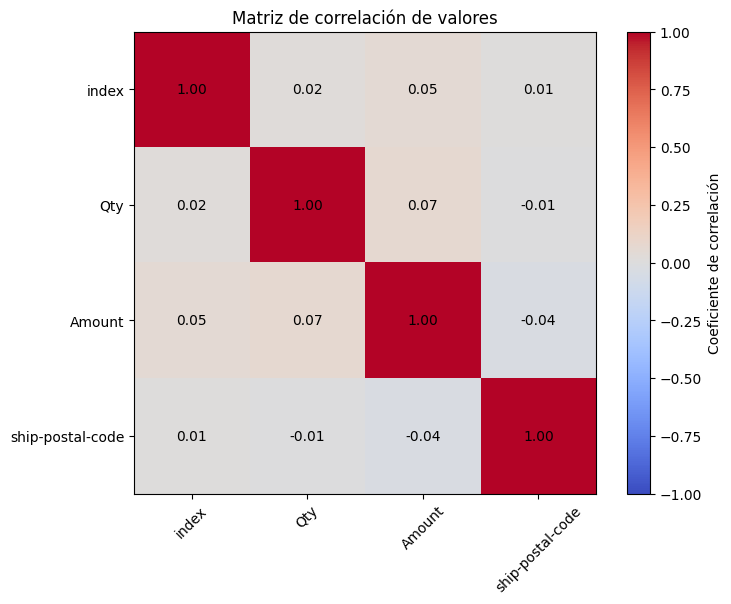

In [13]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar (label="Coeficiente de correlación")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
      plt.text(j,i,f"{corr.iloc[i,j]:.2f}", ha="center",va="center",color="black")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Matriz de correlación de valores")
plt.show()

In [14]:
corr["Amount"].sort_values(ascending=False)

,Amount
Amount,1.000000
Qty,0.066900
index,0.047571
ship-postal-code,-0.038195


**¿Qué variables están altamente correlacionadas con el target?**

En el DataSet, ninguna variable tiene una alta correlacion con el target. La correlacion mas alta es la de Qty, que es la cantidad de producto, por lo que se puede decir que comprar mas productos puede aumentar el monto, pero esto depende del tipo de producto ya que cada producto tiene un precio distinto.

**¿Qué variables para un modelo?**

Algunas variables utiles para un modelo podrian ser:


*   Qty
*   Category

Estas 2 variables tienen una relacion con el target, ya que como se menciono antes, el monto puede verse afectado por la cantidad de producto, pero depende del tipo de producto, ya que los precios varian dependiendo el tipo de producto que se este comprando.

**¿Por qué una alta correlación significa que una variable sea útil?**

Cuando una variable tiene una alta correlacion con el target, significa que cuando la variable aumente o disminuya, el target tambien cambiara de igual forma que la variable. Por esta situacion es que son buenos candidatos para la realizacion de un modelo.

**Interpretación crítica de resultados**

Las variables numericas no explican fuertemente el monto de las ventas. El monto (target) depende de mas variables ademas de las numericas para explicar su aumento o disminucion. Hay varios factores que afectan al monto y no solo un valor nuemrico, sino que las categorias de productos, los tipos, etc. son los que afectan de forma indirecta o directa el monto.

**Selección razonada de variables**



*   Qty: Representa la cantidad de productos comprados.
*   Category: Diferentes productos tienen diferente precio.
*   B2B: Representa las compras empresariales, este tipo de compras suelen ser de grandes cantidades.

